# Online analysis for the IVU transverse impedance measurement

The goal of this notebook is to explore the data during the IVU transverse impedance machine study and progressively extract the quantities needed to estimate the transverse kick factor.

The analysis follows a simple path:

1. Load the data files.
2. Build bunch-to-bunch orbit differences:

\begin{equation}
\Delta u = u_{\rm high} - u_{\rm low},
\qquad u=x,y.
\end{equation}

3. Build current-normalized / charge-normalized orbit differences:

\begin{equation}
\Delta u_{\rm norm}
=
\frac{\Delta u}{\Delta q}.
\end{equation}

4. Check the consistency of the data across turns and acquisitions.
5. Study how $\Delta u$ and $\Delta u/\Delta q$ evolve with the bump $y_0$.
6. Fit the BPM-vector pattern to extract the IVU kick factor for each gap.

The final experimental quantity of interest is the transverse kick factor as a function of gap:

\begin{equation}
k_\perp(g).
\end{equation}

All numerical variables are stored in SI units unless explicitly stated otherwise. Plots may display values in $\mu\mathrm{m}$, $\mathrm{mm}$, or $\mathrm{nC}$ for readability.

## Imports

In [19]:
import os
import sys
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from mathphys.functions import load

parent_dir = os.path.dirname(os.getcwd())
utils_dir = os.path.join(parent_dir, "utils")
sys.path.append(utils_dir)

from ivu_orm import calc_ivu_orm

## Paths and Loading

Data description:

Each data file generated by the acquisition script will be considered as a dictionary with keys:

-  buc1_xpos $\,$ | $\,$ buc1_ypos $\,$ | $\,$ buc1_sum $\:$ ~ $\:$ _all $\,$ (160, n_acq, n_turns)_

-  buc2_xpos $\,$ | $\,$ buc2_ypos $\,$ | $\,$ buc2_sum $\:$ ~ $\:$ _all $\,$ (160, n_acq, n_turns)_


- info (dict):

    - total_current
    - sofb_orbit_x
    - sofb_orbit_y
    - corr_forces
    - timestamp
    - n_acq
    - n_turns

- config (dict):

    - gap
    - y0
    - delta_q_target

- derived (dict):

    - buc1_current
    - buc2_current
    - delta_current
    - buc1_charge
    - buc2_charge
    - delta_charge


### Paths

In [3]:
parent_dir = os.path.dirname(os.getcwd())

meas_data_dir = os.path.join(parent_dir, 'data', 'raw/')  # Real data
synt_data_dir = os.path.join(parent_dir, 'data', 'synthetic/')  # Synthetic data for preliminary tests

# Choose data source
data_dir = synt_data_dir 

In [4]:
file_names = [
    'synt_gap_4mm_dq_1p4nC_y0_1mm.pickle',
    'synt_gap_4mm_dq_1p4nC_y0_1p4mm.pickle',
    'synt_gap_4mm_dq_1p4nC_y0_1p8mm.pickle',
    'synt_gap_4mm_dq_1p4nC_y0_2p2mm.pickle',
    'synt_gap_4mm_dq_2p6nC_y0_1mm.pickle',
    'synt_gap_4mm_dq_2p6nC_y0_1p4mm.pickle',
    'synt_gap_4mm_dq_2p6nC_y0_1p8mm.pickle',
    'synt_gap_4mm_dq_2p6nC_y0_2p2mm.pickle',
    'synt_gap_14mm_dq_1p4nC_y0_1mm.pickle',
    'synt_gap_14mm_dq_1p4nC_y0_1p4mm.pickle',
    'synt_gap_14mm_dq_1p4nC_y0_1p8mm.pickle',
    'synt_gap_14mm_dq_1p4nC_y0_2p2mm.pickle',
    'synt_gap_14mm_dq_2p6nC_y0_1mm.pickle',
    'synt_gap_14mm_dq_2p6nC_y0_1p4mm.pickle',
    'synt_gap_14mm_dq_2p6nC_y0_1p8mm.pickle',
    'synt_gap_14mm_dq_2p6nC_y0_2p2mm.pickle'
 ]

file_paths = [data_dir + file for file in file_names]

for file_path in file_paths:
    print(file_path)

/home/henrique.silvestre/fac-henrique/coding/machine_studies/2026-08-17-SI_IVU_impedance_measurement/data/synthetic/synt_gap_4mm_dq_1p4nC_y0_1mm.pickle
/home/henrique.silvestre/fac-henrique/coding/machine_studies/2026-08-17-SI_IVU_impedance_measurement/data/synthetic/synt_gap_4mm_dq_1p4nC_y0_1p4mm.pickle
/home/henrique.silvestre/fac-henrique/coding/machine_studies/2026-08-17-SI_IVU_impedance_measurement/data/synthetic/synt_gap_4mm_dq_1p4nC_y0_1p8mm.pickle
/home/henrique.silvestre/fac-henrique/coding/machine_studies/2026-08-17-SI_IVU_impedance_measurement/data/synthetic/synt_gap_4mm_dq_1p4nC_y0_2p2mm.pickle
/home/henrique.silvestre/fac-henrique/coding/machine_studies/2026-08-17-SI_IVU_impedance_measurement/data/synthetic/synt_gap_4mm_dq_2p6nC_y0_1mm.pickle
/home/henrique.silvestre/fac-henrique/coding/machine_studies/2026-08-17-SI_IVU_impedance_measurement/data/synthetic/synt_gap_4mm_dq_2p6nC_y0_1p4mm.pickle
/home/henrique.silvestre/fac-henrique/coding/machine_studies/2026-08-17-SI_IVU_i

### Loading

#### Real

In [5]:
# data = []
# for file_path in file_paths:
#     data_i = load(file_path)
#     data.append(data_i['data'])

# data[i] will be the dictionary with data from the i-th acquisition

# n_configs = len(data)  # []

# print(f"Loaded {n_configs} configurations.")


#### Synthetic

Using synthetic data to get some intuition

In [6]:
# Structure of the data stored in each pickle file:

# data = {
#     "buc1_xpos": buc1_xpos,
#     "buc2_xpos": buc2_xpos,
#     "buc1_ypos": buc1_ypos,
#     "buc2_ypos": buc2_ypos,
#     "buc1_sum": buc1_sum,
#     "buc2_sum": buc2_sum,

#     "info": {
#         "total_current": total_current,
#         "sofb_orbit_x": sofb_orbit_x,
#         "sofb_orbit_y": sofb_orbit_y,
#         "corr_forces": corr_forces,
#         "timestamp": timestamp,
#         "n_acq": n_acq,
#         "n_turns": n_turns,
#     },

#     "config": {
#         "gap": gap,
#         "y0": y0,
#         "delta_q_target": delta_q,
#     },

#     "derived": {
#         "buc1_current": buc1_current,
#         "buc2_current": buc2_current,
#         "delta_current": delta_current,
#         "buc1_charge": buc1_charge,
#         "buc2_charge": buc2_charge,
#         "delta_charge": delta_q,
#     },
# 
#     "synthetic_truth": {
#         "kperp_x": kperp_x[gap],
#         "kperp_y": kperp_y[gap],
#         "a_x": a_x,
#         "a_y": a_y,
#         "c_x": c_x,
#         "c_y": c_y,
#     },
# }

In [7]:
data = []

for file_path in file_paths:
    data_i = load(file_path)
    data.append(data_i)

n_configs = len(data)  # []

print(f"Loaded {n_configs} configurations.")


Loaded 16 configurations.


## First data checks

In [8]:
data_check = data[0]

print("\ndata[i]:")
print(data_check.keys())

print("\nShapes:")
print("buc1_ypos:", data_check["buc1_ypos"].shape)

print("\n'config':")
print(data_check["config"])

print("\n'info' keys:")
print(data_check["info"].keys())

print("\n'derived' keys:")
print(data_check["derived"].keys())

print("\n\nCurrents and charges:")
print(rf'Total current: {1e3*data_check["info"]["total_current"]:.2f} mA')
print(rf'Bunch 1 current: {1e3*data_check["derived"]["buc1_current"]:.2f} mA')
print(rf'Bunch 2 current: {1e3*data_check["derived"]["buc2_current"]:.2f} mA')
print(rf'Delta current: {1e3*data_check["derived"]["delta_current"]:.2f} mA')
print(rf'Delta charge: {1e9*data_check["derived"]["delta_charge"]:.2f} nC')


data[i]:
dict_keys(['buc1_xpos', 'buc2_xpos', 'buc1_ypos', 'buc2_ypos', 'buc1_sum', 'buc2_sum', 'info', 'config', 'derived', 'synthetic_truth'])

Shapes:
buc1_ypos: (160, 20, 10)

'config':
{'gap': 0.004, 'y0': 0.001, 'delta_q_target': 1.4e-09}

'info' keys:
dict_keys(['total_current', 'sofb_orbit_x', 'sofb_orbit_y', 'corr_forces', 'timestamp', 'n_acq', 'n_turns'])

'derived' keys:
dict_keys(['buc1_current', 'buc2_current', 'delta_current', 'buc1_charge', 'buc2_charge', 'delta_charge'])


Currents and charges:
Total current: 1.04 mA
Bunch 1 current: 0.93 mA
Bunch 2 current: 0.12 mA
Delta current: 0.81 mA
Delta charge: 1.40 nC


## Create a configuration table

In [9]:
def make_config_table(data):
    """Create table with the main configuration parameters.

    Args:
        data (list): List of data dictionaries.

    Returns:
        config_table (pandas.DataFrame): Table with one row per configuration.

    """
    rows = []

    for i, data_i in enumerate(data):
        config = data_i["config"]
        derived = data_i["derived"]
        info = data_i["info"]

        rows.append({
            "cfg": i,
            "gap": config["gap"],
            "y0": config["y0"],
            "delta_q_target": config["delta_q_target"],
            "delta_charge": derived["delta_charge"],
            "delta_current": derived["delta_current"],
            "total_current": info["total_current"],
        })

    config_table = pd.DataFrame(rows)
    return config_table

In [10]:
config_table = make_config_table(data)
config_table

,cfg,gap,y0,delta_q_target,delta_charge,delta_current,total_current
0,0,0.004,0.0010,1.400000e-09,1.400000e-09,0.000810,0.001041
1,1,0.004,0.0014,1.400000e-09,1.400000e-09,0.000810,0.001041
2,2,0.004,0.0018,1.400000e-09,1.400000e-09,0.000810,0.001041
3,3,0.004,0.0022,1.400000e-09,1.400000e-09,0.000810,0.001041
4,4,0.004,0.0010,2.600000e-09,2.600000e-09,0.001504,0.001735
5,5,0.004,0.0014,2.600000e-09,2.600000e-09,0.001504,0.001735
6,6,0.004,0.0018,2.600000e-09,2.600000e-09,0.001504,0.001735
7,7,0.004,0.0022,2.600000e-09,2.600000e-09,0.001504,0.001735
8,8,0.014,0.0010,1.400000e-09,1.400000e-09,0.000810,0.001041
9,9,0.014,0.0014,1.400000e-09,1.400000e-09,0.000810,0.001041


Or for better readability:

In [11]:
# config_table_view = config_table.copy()

# config_table_view["gap_mm"] = 1e3 * config_table_view["gap"]
# config_table_view["y0_mm"] = 1e3 * config_table_view["y0"]
# config_table_view["delta_q_nC"] = 1e9 * config_table_view["delta_charge"]
# config_table_view["delta_current_mA"] = 1e3 * config_table_view["delta_current"]

# config_table_view[[
#     "cfg",
#     "gap_mm",
#     "delta_q_nC",
#     "y0_mm",
#     "delta_current_mA",
# ]]

## Build orbit-difference arrays

For each configuration, the bunch $x$ and $y$ signals (${x_1}$, ${x_2}$, ${x_{sum}}$, ${y_1}$, ${y_2}$, ${y_{sum}}$) have shape:

\begin{equation}
(160,\ n_{\rm acq},\ n_{\rm turns}).
\end{equation}

After stacking all configurations, the corresponding orbit arrays have shape:

\begin{equation}
(n_{\rm configs},\ 160,\ n_{\rm acq},\ n_{\rm turns}).
\end{equation}

We then define:

\begin{equation}
\Delta x = x_1 - x_2,
\qquad
\Delta y = y_1 - y_2.
\end{equation}

We also define the charge-normalized quantities:

\begin{equation}
\Delta x_{\rm norm} = \frac{\Delta x}{\Delta q},
\qquad
\Delta y_{\rm norm} = \frac{\Delta y}{\Delta q}.
\end{equation}

To generalize for both planes, we can call these orbit differences $\Delta u$ and $\Delta u_{\rm norm}$, which will be the names used throught this notebook.

In [12]:
def stack_orbit_data(data, plane="y"):
    """Stack bunch orbit data for one plane.

    Args:
        data (list): List of data dictionaries.
        plane (str, optional): Transverse plane. Use 'x' or 'y'.

    Returns:
        buc1_pos (numpy.ndarray): Bunch 1 position array [m].
        buc2_pos (numpy.ndarray): Bunch 2 position array [m].
        delta_pos (numpy.ndarray): Bunch-to-bunch difference [m].

    """
    if plane == "x":
        key1 = "buc1_xpos"
        key2 = "buc2_xpos"
    elif plane == "y":
        key1 = "buc1_ypos"
        key2 = "buc2_ypos"
    else:
        raise ValueError("plane must be 'x' or 'y'.")

    buc1_pos = np.array([data_i[key1] for data_i in data])  # [m]
    buc2_pos = np.array([data_i[key2] for data_i in data])  # [m]

    delta_pos = buc1_pos - buc2_pos  # [m]

    return buc1_pos, buc2_pos, delta_pos


def normalize_by_charge(delta_pos, config_table):
    """Normalize orbit difference by bunch charge difference.

    Args:
        delta_pos (numpy.ndarray): Bunch-to-bunch orbit difference [m].
        config_table (pandas.DataFrame): Configuration table.

    Returns:
        delta_pos_norm (numpy.ndarray): Charge-normalized orbit difference [m/C].

    """
    delta_q = config_table["delta_charge"].to_numpy()  # [C]
    delta_pos_norm = delta_pos / delta_q[:, None, None, None]  # [m/C]
    
    return delta_pos_norm

In [13]:
delta_q = config_table["delta_charge"].to_numpy()
print(delta_q[:, None, None, None].shape)

(16, 1, 1, 1)


In [14]:
buc1_ypos, buc2_ypos, delta_ypos = stack_orbit_data(data, plane="y")
buc1_xpos, buc2_xpos, delta_xpos = stack_orbit_data(data, plane="x")

delta_ypos_norm = normalize_by_charge(delta_ypos, config_table)
delta_xpos_norm = normalize_by_charge(delta_xpos, config_table)

print("delta_ypos shape      :", delta_ypos.shape)
print("delta_ypos_norm shape :", delta_ypos_norm.shape)
print("delta_xpos shape      :", delta_xpos.shape)
print("delta_xpos_norm shape :", delta_xpos_norm.shape)

delta_ypos shape      : (16, 160, 20, 10)
delta_ypos_norm shape : (16, 160, 20, 10)
delta_xpos shape      : (16, 160, 20, 10)
delta_xpos_norm shape : (16, 160, 20, 10)


## First plots

### Helpers

In [15]:
def get_delta_u(plane="y", normalized=False):
    """Get orbit-difference array for one plane (Delta u).

    Args:
        plane (str): Transverse plane. use 'x' or 'y'.
        normalized (bool): Whether Delta u is charge-normalized.
            
    Returns:
        delta_u (numpy.ndarray): Orbit-difference array. 
            Shape (n_configs, n_bpms, n_acq, n_turns).

    """
    if plane == "x":
        delta_u = delta_xpos_norm if normalized else delta_xpos
    elif plane == "y":
        delta_u = delta_ypos_norm if normalized else delta_ypos
    else:
        raise ValueError("plane must be 'x' or 'y'.")

    return delta_u


def get_plot_scale(plane="y", normalized=False):
    """Get scale and label for plotting.

    Args:
        plane (str): Transverse plane. use 'x' or 'y'.
        normalized (bool): Whether Delta u is charge-normalized.

    Returns:
        scale (float): Multiplicative scale.
        ylabel (str): Axis label.

    """
    if normalized:
        scale = 1e-3
        ylabel = rf"$\Delta {plane} / \Delta q$ [$\mu$m/nC]"
    else:
        scale = 1e6
        ylabel = rf"$\Delta {plane}$ [$\mu$m]"

    return scale, ylabel

### One configuration, acquisition and turn

Considering the full position displacement vector for the plane $u$, $\mathbf{\Delta u}$, we can write the element corresponding to configuration $c$, BPM $i$, acquisition $j$, and turn $k$, as:

\begin{equation}
\Delta u(c,i,j,k),
\end{equation}

Then, to begin, let's select one configuration, acquisition and turn (i.e., fixed $c$, $j$, and $k$), and plot the full $\Delta u_{c,j,k} (i)$ profile across the ring. 

First, we can quickly get ``spos_bpms`` using the _calc_ivu_orm_ function, which will be handful for the plots.

In [20]:
_, orm_info = calc_ivu_orm(delta_vkick=5e-6, ivu_number=1)
spos_bpms = orm_info["spos_bpms"]  # [m]

In [21]:
def plot_single_profile(cfg=0, acq=0, turn=0, plane="y", normalized=False):
    """Plot Delta u profile across BPMs for one configuration, acquisition and turn.

    Args:
        cfg (int): Configuration index.
        acq (int): Acquisition index.
        turn (int): Turn index.
        plane (str): Transverse plane.
        normalized (bool): Whether Delta u is charge-normalized.

    """
    delta_u = get_delta_u(plane=plane, normalized=normalized)
    scale, ylabel = get_plot_scale(plane=plane,normalized=normalized)

    profile = delta_u[cfg, :, acq, turn]

    row = config_table.iloc[cfg]

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(spos_bpms, scale * profile, ".-")

    ax.set_title(
        rf"{normalized*'Charge-norm. '}"
        rf"$\Delta {plane}$ profile, cfg={cfg}, acq={acq}, turn={turn} "
        rf"(gap={1e3*row['gap']:.1f} mm, "
        rf"$\Delta q$={1e9*row['delta_charge']:.1f} nC, "
        rf"$y_0$={1e3*row['y0']:.1f} mm)"
    )
    ax.set_xlabel("spos [m]")
    ax.set_ylabel(ylabel)
    ax.grid(True)
    plt.show()

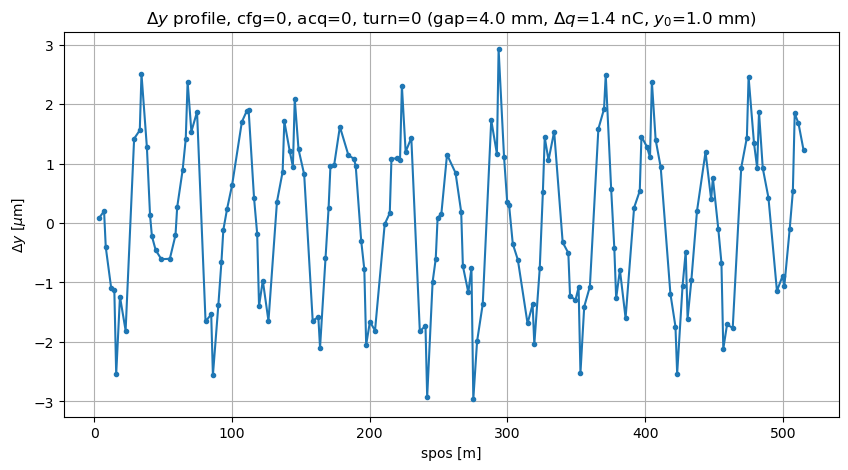

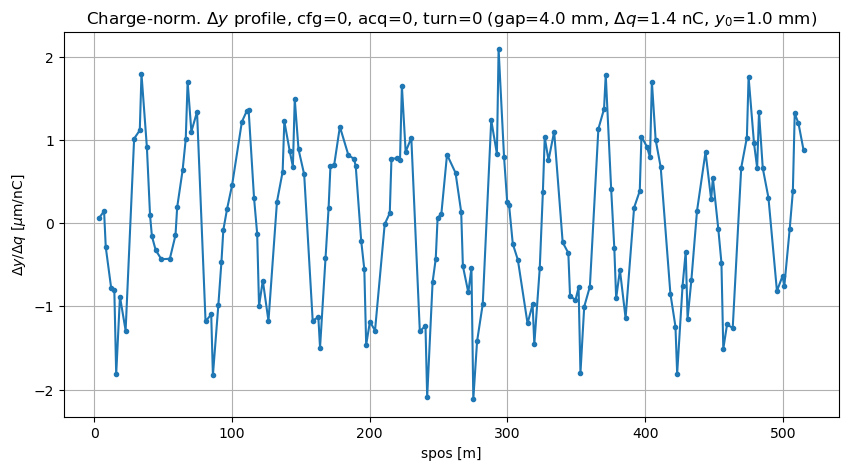

In [22]:
plot_single_profile(cfg=0, acq=0, turn=0, plane="y", normalized=False)
plot_single_profile(cfg=0, acq=0, turn=0, plane="y", normalized=True)

### One Configuration and one aquisition

Now, let's overlay all turns from one acquisition $-$ meaning: plot $\Delta u_{c,j,k} (i)$ for all $k's$.

It helps us see whether the turn-to-turn fluctuations are small, or whether the full BPM profile changes significantly inside one acquisition.

In [23]:
def plot_turns_in_acquisition(cfg=0, acq=0, plane="y", normalized=False, legend=False):
    """Plot Delta u profiles across BPMs for all turns inside one acquisition.

    Args:
        cfg (int): Configuration index.
        acq (int): Acquisition index.
        plane (str): Transverse plane.
        normalized (bool): Whether Delta u is charge-normalized.
        legend(bool): Whether to include legend.

    """
    delta_u = get_delta_u(plane=plane, normalized=normalized)
    scale, ylabel = get_plot_scale(normalized=normalized)

    row = config_table.iloc[cfg]

    fig, ax = plt.subplots(figsize=(10, 5))

    for turn in range(delta_u.shape[3]):
        profile = delta_u[cfg, :, acq, turn]
        ax.plot(spos_bpms, scale * profile, ".-", alpha=0.4, label=rf'turn {turn}')

    ax.set_title(
        rf"{normalized*'Charge-norm. '}"
        rf"$\Delta {plane}$ per turn, cfg={cfg}, acq={acq} "
        rf"(gap={1e3*row['gap']:.1f} mm, "
        rf"$\Delta q$={1e9*row['delta_charge']:.1f} nC, "
        rf"$y_0$={1e3*row['y0']:.1f} mm)"
    )
    ax.set_xlabel("spos [m]")
    ax.set_ylabel(ylabel)
    ax.grid(True)
    if legend: ax.legend()
    plt.show()

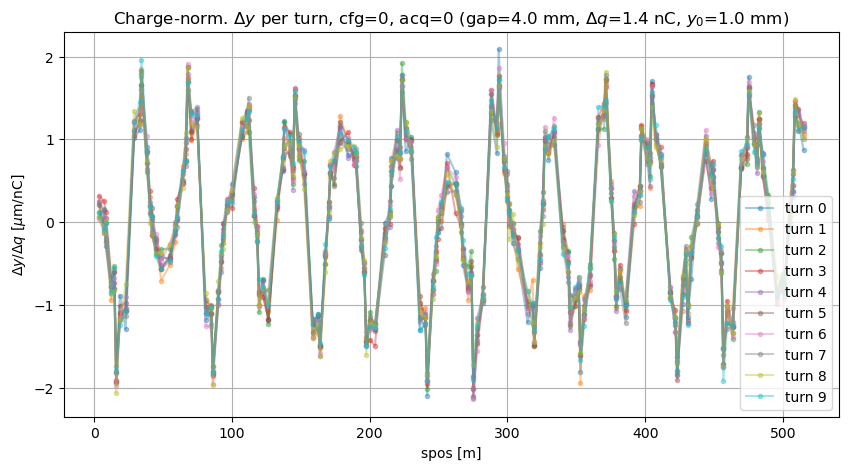

In [24]:
plot_turns_in_acquisition(cfg=0, acq=0, plane="y", normalized=True, legend=True)

We can also see the turn-distribution for a single BPM.

(i.e., plot $\Delta u_{c,i,j}(k)$)

In [25]:
def plot_one_bpm_one_acquisition(cfg=0, acq=0, bpm=0, plane="y", normalized=False):
    """Plot, for one BPM, the Delta u profile across turns for one acquisition.

    Args:
        cfg (int): Configuration index.
        acq (int): Acquisition index.
        bpm (int): BPM index.
        plane (str): Transverse plane.
        normalized (bool): Whether Delta u is charge-normalized.

    """
    delta_u = get_delta_u(plane=plane, normalized=normalized)
    scale, ylabel = get_plot_scale(plane=plane,normalized=normalized)

    row = config_table.iloc[cfg]

    fig, ax = plt.subplots(figsize=(10, 5))

    bpm_profile = delta_u[cfg, bpm, acq, :]
    turns = range(delta_u.shape[3])
    ax.plot(turns, scale * bpm_profile, ".-", alpha=0.4)

    ax.set_title(
        rf"{normalized*'Charge-norm. '}"
        rf"$\Delta {plane}$ BPM {bpm}, all turns, cfg={cfg}, acq={acq} "
        rf"(gap={1e3*row['gap']:.1f} mm, "
        rf"$\Delta q$={1e9*row['delta_charge']:.1f} nC, "
        rf"$y_0$={1e3*row['y0']:.1f} mm)"
    )
    ax.set_xlabel("turn idx []")
    ax.set_ylabel(ylabel)
    ax.grid(True)
    plt.show()

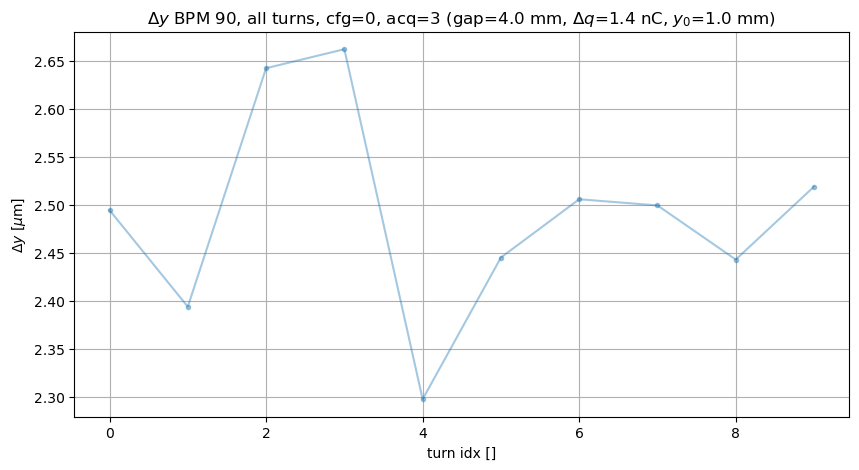

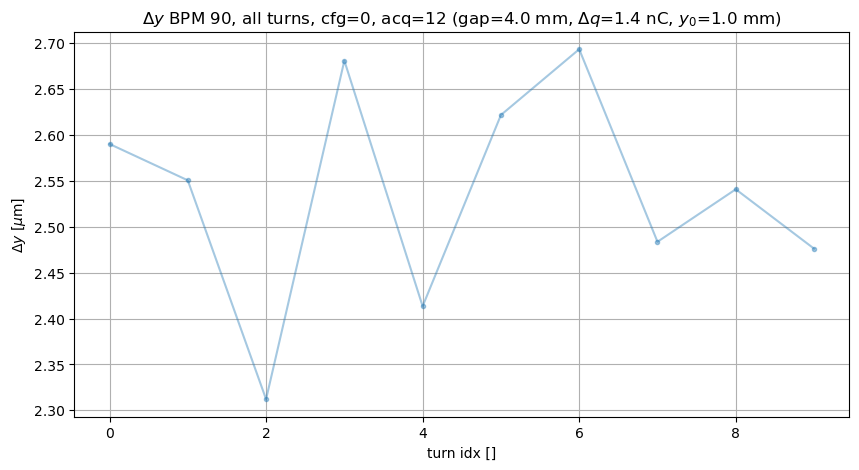

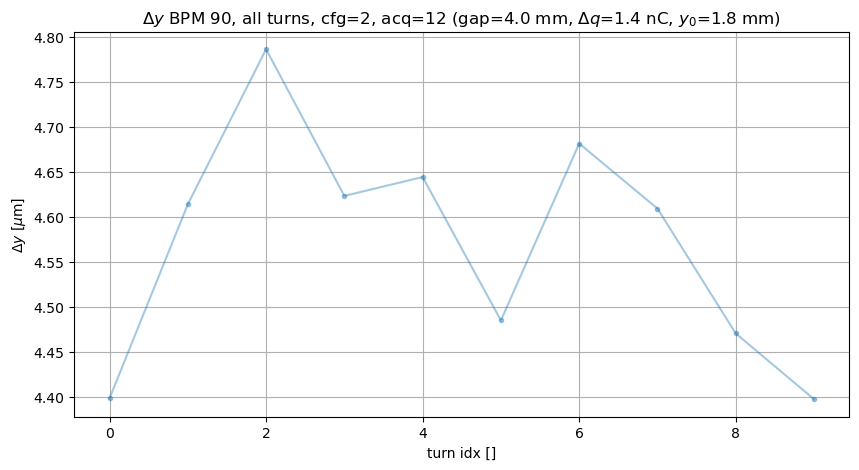

In [26]:
plot_one_bpm_one_acquisition(cfg=0, acq=3, bpm=90, normalized=False)
plot_one_bpm_one_acquisition(cfg=0, acq=12, bpm=90, normalized=False)
plot_one_bpm_one_acquisition(cfg=2, acq=12, bpm=90, normalized=False)

### Mean profile per acquisition

For each acquisition, we can average over turns (index $k$):

\begin{equation}
\langle \Delta u \rangle_{\rm turns}(c,i,j)
=
\langle \Delta u \rangle_{\rm k}(c,i,j)
=
\frac{1}{n_{\rm turns}}
\sum_k
\Delta u(c,i,j,k).
\end{equation}

And also calculate the corresponding $std$:

\begin{equation}
\mathrm{std}_{k}
\left[
\Delta u(c,i,j,k)
\right],
\end{equation}

which can give a first estimate of the stability inside each acquisition.

In [27]:
def plot_acquisition_means(cfg=0, acqs='all', plane="y", normalized=False, stds=False, legend=False):
    """Plot mean Delta u profile with stds for specified acquisitions of one configuration.

    Args:
        cfg (int): Configuration index.
        acqs (list): Aquisitions to plot. Defaults to 'all', plotting all 
            available ones.
        plane (str): Transverse plane.
        normalized (bool, optional): Whether Delta u is charge-normalized.
        legend (bool): Whether to include legend.

    """
    delta_u = get_delta_u(plane=plane, normalized=normalized)
    scale, ylabel = get_plot_scale(plane=plane,normalized=normalized)

    delta_u_cfg = delta_u[cfg]  # [m] or [m/C]
    mean_by_acq = np.mean(delta_u_cfg, axis=2)  # [n_bpms, n_acq]
    std_by_acq = np.std(delta_u_cfg, axis=2)  # [n_bpms, n_acq]

    row = config_table.iloc[cfg]

    if acqs == 'all':
            acqs = range(mean_by_acq.shape[1])

    fig, ax = plt.subplots(figsize=(10, 5))

    for acq in acqs:
        if stds:
            ax.errorbar(
                spos_bpms,
                scale * mean_by_acq[:, acq],
                yerr=scale * std_by_acq[:, acq],
                marker=".",
                capsize=3,
                label=rf'acq {acq}'
            )
        else:
             ax.plot(
                spos_bpms,
                scale * mean_by_acq[:, acq],
                '.-',
                alpha=0.4,
                label=rf'acq {acq}'
             )

    ax.set_title(
        rf"{normalized*'Charge-norm. '}"
        rf"$\langle\Delta {plane}\rangle$ profile per acquisition, cfg={cfg} "
        rf"(gap={1e3*row['gap']:.1f} mm, "
        rf"$\Delta q$={1e9*row['delta_charge']:.1f} nC, "
        rf"$y_0$={1e3*row['y0']:.1f} mm)"
    )
    ax.set_xlabel("spos [m]")
    ax.set_ylabel(ylabel)
    ax.grid(True)
    if legend: ax.legend()
    plt.show()


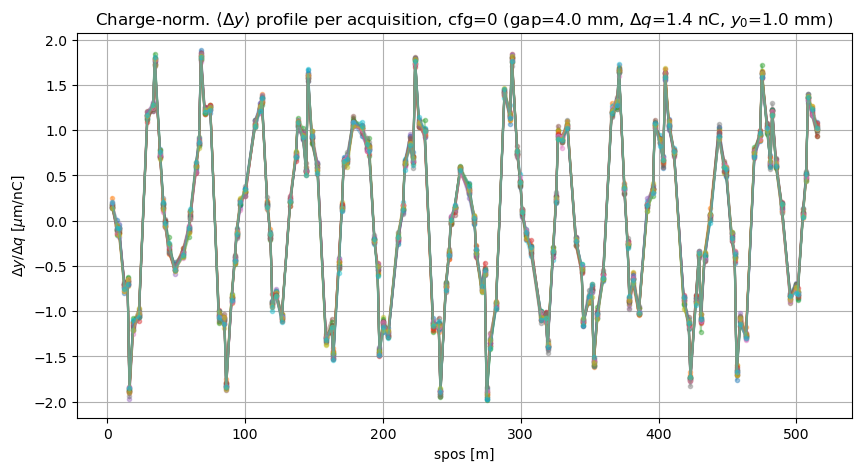

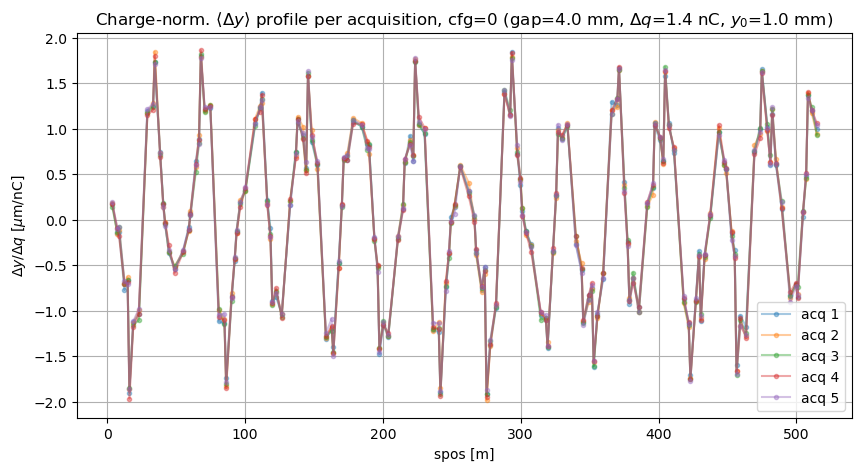

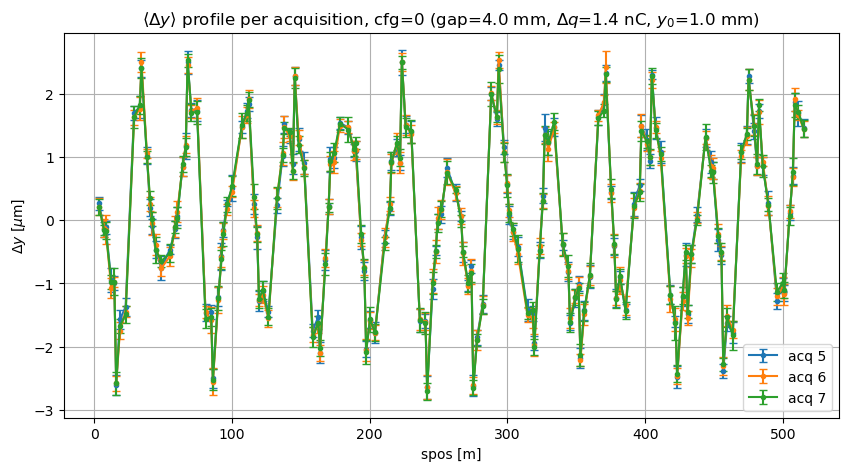

In [28]:
plot_acquisition_means(cfg=0, plane="y", normalized=True)
plot_acquisition_means(cfg=0, plane="y", acqs=range(1,6), normalized=True, legend=True)
plot_acquisition_means(cfg=0, plane="y", acqs=range(5,8), normalized=False, stds=True, legend=True)


### Mean profile for one configuration

Now, for each configuration, we can average over all acquisitions and turns:

\begin{equation}
\overline{\Delta u}(c,i)
=
\left\langle \Delta u \right\rangle_{j,k}(c,i) = 
\frac{1}{n_{\rm acq}n_{\rm turns}} \sum_{j,k} \Delta u(c,i,j,k).
\end{equation}

_(reminder: $c$ refers to config. index, $i$ to BPM index, $j$ to acquisition index, and $k$ to turn index)_

And we also calculate the standard deviation:

\begin{equation}
\sigma_{\Delta u}(c,i)
=
\mathrm{std}_{j,k}
\left[
\Delta u_(c,i,j,k)
\right].
\end{equation}

**Resulting in arrays $\overline{\Delta u}$ and $\sigma_{\Delta u}$ of dimensions** (*n_configs, n_bpms*) **, which will be central for the subsequent analyses.**

In [29]:
def process_delta_u(delta_u):
    """Calculate mean, std and standard error of Delta u for each
        configuration.

    Args:
        delta_u (numpy.ndarray): Orbit-difference array with shape
            (n_configs, n_bpms, n_acq, n_turns).

    Returns:
        processed (dict): Dictionary with mean, std and sem arrays.

    """
    mean = np.mean(delta_u, axis=(2, 3))  # []
    std = np.std(delta_u, axis=(2, 3))  # []

    n_samples = delta_u.shape[2] * delta_u.shape[3]  # []
    sem = std / np.sqrt(n_samples)  # []

    processed = {
        "mean": mean,
        "std": std,
        "sem": sem,
    }

    return processed

In [30]:
processed_y = process_delta_u(delta_ypos)
processed_y_norm = process_delta_u(delta_ypos_norm)

processed_x = process_delta_u(delta_xpos)
processed_x_norm = process_delta_u(delta_xpos_norm)

In [31]:
print(processed_y['mean'].shape)

(16, 160)


Plot one (or some) processed configuration(s):

In [32]:
def plot_config_mean(cfgs=[0], plane="y", normalized=False, use_sem=False):
    """Plot mean profile and error bars for one configuration.

    Args:
        cfgs (list): Configuration indexes.
        plane (str): Transverse plane.
        normalized (bool): Whether Delta u is charge normalized.
        use_sem (bool): Use standard error instead of std.

    """
    if plane == "y":
        processed = processed_y_norm if normalized else processed_y
    elif plane == "x":
        processed = processed_x_norm if normalized else processed_x
    else:
        raise ValueError("plane must be 'x' or 'y'.")

    scale, ylabel = get_plot_scale(normalized=normalized)

    fig, ax = plt.subplots(figsize=(10, 5))

    for cfg in cfgs:
        mean = processed["mean"][cfg]  # []
        err_key = "sem" if use_sem else "std"
        err = processed[err_key][cfg]  # []

        row = config_table.iloc[cfg]

        ax.errorbar(
            spos_bpms,
            scale * mean,
            yerr= scale * err,
            marker=".",
            capsize=3,
            alpha=0.7,
            label=rf"$gap$={1e3*row['gap']:.1f} mm | $\Delta q$={1e9*row['delta_charge']:.1f} nC | $y_0$={1e3*row['y0']:.1f} mm"
        )

    ax.set_title(
        rf"{normalized*'Charge-norm. '}"
        rf"$\langle\Delta {plane}$"
        r"$\rangle_{acqs,turns}$ profile"
    )
    ax.set_xlabel("spos [m]")
    ax.set_ylabel(ylabel)
    ax.grid(True)
    ax.legend()
    plt.show()

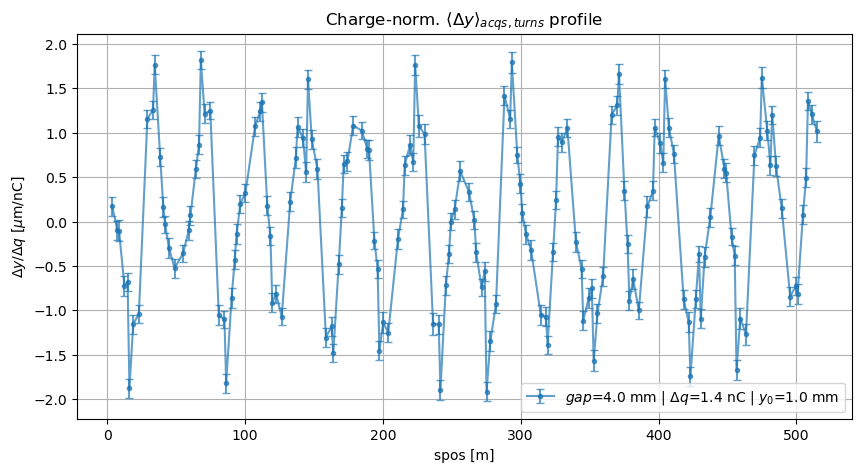

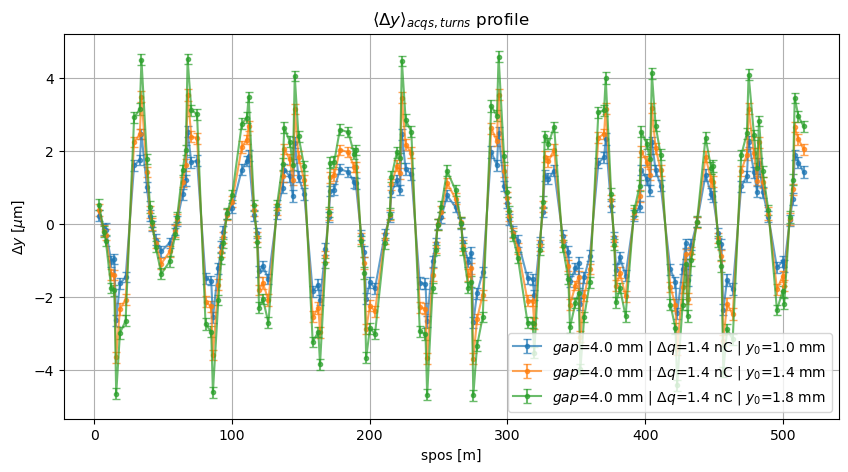

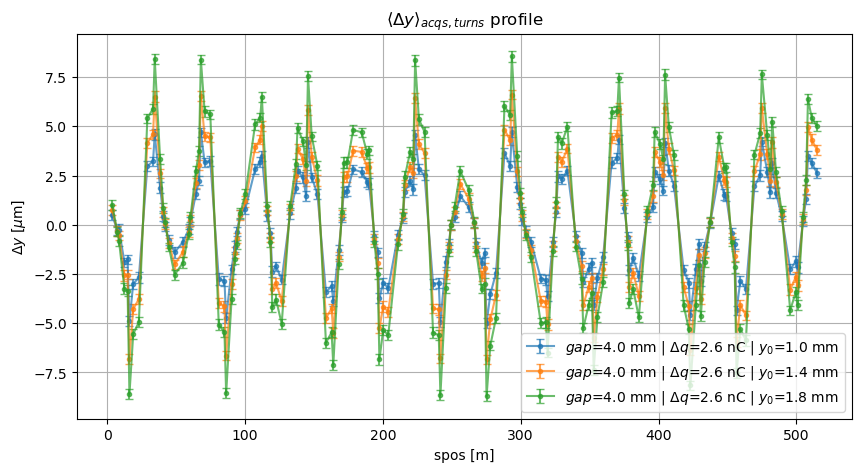

In [33]:
plot_config_mean(cfgs=[0], plane="y", normalized=True)
plot_config_mean(cfgs=range(0,3), plane="y", normalized=False)
plot_config_mean(cfgs=range(4,7), plane="y", normalized=False)

### Single BPM view: $\overline{\Delta u}_i$ versus $y_0$

Before doing a fit for each configuration using all BPMs, it is useful to look at individual BPMs to see if $\overline{\Delta u}_i(\Delta q, y_0)$ follows the expected behavior.

For one BPM and one gap, we can plot:

\begin{equation}
    \overline{\Delta u_i}
\quad \text{vs} \quad y_0
\end{equation}

for different values of $\Delta q$. 

**We expect $\overline{\Delta u_i}$ to grow approx. linearly with both $\Delta q$ and $y_0$.**

Then, we'll plot:

\begin{equation}
\frac{\Delta u_i}{\Delta q}
\quad \text{vs} \quad y_0.
\end{equation}

And if the signal follows the expected charge dependence, curves with different $\Delta q$ should approximately collapse in the normalized plot!

In [34]:
def get_processed(plane="y", normalized=False):
    """Get chosen processed data.

    Args:
        plane (str): Transverse plane.
        normalized (bool): Whether to use charge-normalized Delta u.

    Returns:
        processed (dict): Processed data dictionary.

    """
    if plane == "y":
        processed = processed_y_norm if normalized else processed_y
    elif plane == "x":
        processed = processed_x_norm if normalized else processed_x
    else:
        raise ValueError("plane must be 'x' or 'y'.")

    return processed

In [35]:
def plot_delta_u_bpm_vs_y0(bpm=0, gap=None, plane="y", normalized=False):
    """Plot processed Delta u for one BPM as a function of y0.

    Args:
        bpm (int): BPM index.
        gap (float): IVU gap [m].
        plane (str): Transverse plane.
        normalized (bool): Whether to use charge-normalized Delta u.

    """
    if gap is None:
        gap = config_table["gap"].unique()[0]

    processed = get_processed(plane=plane, normalized=normalized)
    scale, ylabel = get_plot_scale(plane=plane,normalized=normalized)

    mean = processed["mean"][:, bpm]  # []
    std = processed["std"][:, bpm]  # []

    bpm_spos = spos_bpms[bpm]  # [m]

    fig, ax = plt.subplots(figsize=(8, 5))

    delta_q_values_unique = np.sort(config_table["delta_charge"].unique())

    for delta_q in delta_q_values_unique:
        mask = (
            np.isclose(config_table["gap"], gap, rtol=0, atol=1e-12)
            & np.isclose(
                config_table["delta_charge"],
                  delta_q,
                  rtol=0,
                  atol=1e-12
            )
        )

        idx = config_table.index[mask].to_numpy()

        y0_vals = config_table.loc[idx, "y0"].to_numpy()
        order = np.argsort(y0_vals)

        idx = idx[order]
        y0_vals = y0_vals[order]

        ax.errorbar(
            1e3 * y0_vals,
            scale * mean[idx],
            yerr=scale * std[idx],
            marker="o",
            capsize=3,
            label=rf"$\Delta q$ = {1e9*delta_q:.1f} nC",
        )

    ax.set_title(
        rf"{normalized*'Charge-norm. '}"
        rf"$\Delta {plane}$ vs $y_0$, BPM {bpm}"
        rf", gap = {1e3*gap:.1f} mm"
    )
    ax.set_xlabel(r"$y_0$ [mm]")
    ax.set_ylabel(ylabel)
    ax.grid(True)
    ax.legend()
    plt.show()

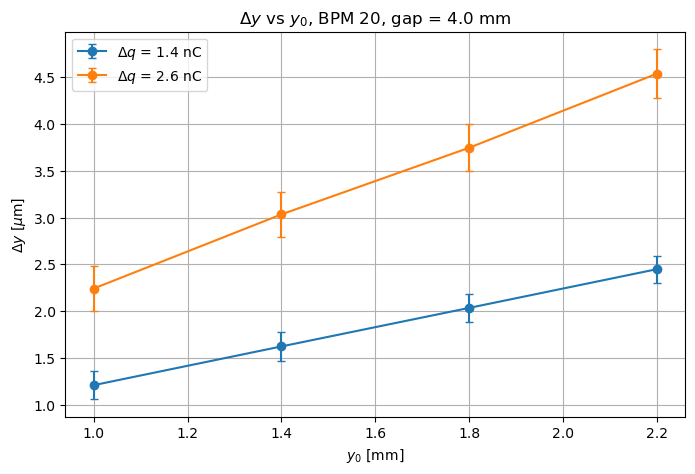

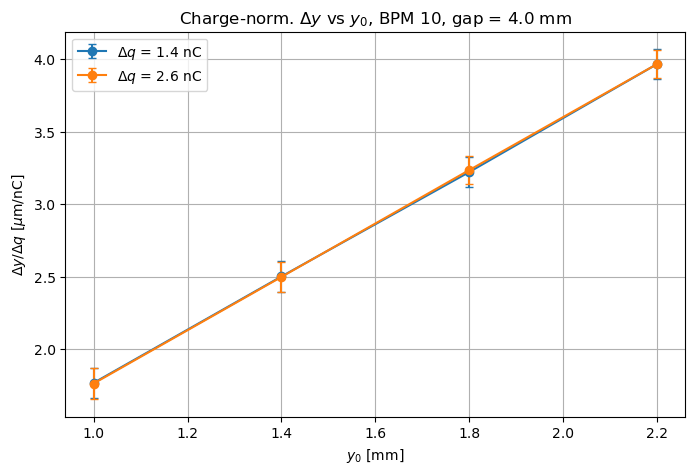

In [36]:
plot_delta_u_bpm_vs_y0(bpm=20, gap=4.0e-3, plane="y", normalized=False)
plot_delta_u_bpm_vs_y0(bpm=10, gap=4.0e-3, plane="y", normalized=True)

## Global BPM-vector fit

Until now, we explored the data in a local way:

- one configuration;
- one acquisition;
- one BPM;
- one gap;
- one value of $y_0$;
- one value of $\Delta q$.

Now we want to use the full BPM vector to estimate the transverse kick factor.

For each configuration $\rm cfg$, we have the processed charge-normalized orbit difference:

\begin{equation}
    \mathbf{v^u_{\rm cfg}}\left( \frac{\overline{\Delta \mathbf u}}{\Delta q} \right)_{\rm cfg} ,
\end{equation}

where $u=x$ or $y$.

For a fixed gap $g$, the model is:

\begin{equation}
\left( \frac{\overline{\Delta \mathbf u}}{\Delta q} \right)_{\rm cfg}
=
\mathbf c^u
+
y_{0,c}\mathbf M_{\rm IVU} a^u(g)
+
\boldsymbol\epsilon_{\rm cfg}^u.
\end{equation}

where:

\begin{equation}
a^u(g)=\frac{k^u_\perp(g)}{E/e}.
\end{equation}

Here:

- $\mathbf{\left( \frac{\overline{\Delta u}}{\Delta q} \right)_{\rm cfg}}$ is the measured charge-normalized orbit-difference vector;
- $\mathbf c^u$ is a BPM-by-BPM offset/background;
- $\mathbf M_{\rm IVU}$ is the orbit response column of the IVU;
- $y_{0,c}$ is the bump amplitude;
- $a^u(g)$ is the fitted coefficient;
- $k^u_\perp(g)$ is the transverse kick factor.
- $\boldsymbol\epsilon_{\rm cfg}^u$ is a random noise representing fluctuations on the charge-dependent orbit effect.

The goal of the fit is to estimate $a(g)$, and then calculate:

\begin{equation}
k_\perp(g) = (E/e)a(g).
\end{equation}

## Theoretical Kick Factors

In [1]:
import pycolleff.impedances as imp
import pycolleff.materials_params as mat_par

### Define Chamber Parameters

### Round Chamber

### Flat Chamber

### Plot/Compare Impedances

### Calculate Kick Factors

The kick factor is defined as:

\begin{equation}
    k_\perp^u = \frac{1}{\pi} \int_0^\infty ImZ_\perp^u(\omega)\left|\lambda(\omega)\right|^2d\omega
    \end{equation}

where $\left|\lambda(\omega)\right|^2$ is the bunch power spectrum $-$ $\lambda(\omega)$ is the Fourier transform of $\lambda(t)$, the bunch linear charge density.

In our case, $Z_\perp^u$ will correspond solely to the dipolar impedances $Z^D_x$ or $Z^D_y$.
